In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

In [3]:
df = pd.read_csv('/Users/elenagarriguespascual/Desktop/Ironhack/WEEK5/amz_uk_price_prediction_dataset.csv')

In [4]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [5]:
df.shape

(2443651, 9)

PART 1: Understanding Product Categories

Business Question: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

1.1 Generate a frequency table for the product "category"

In [6]:
frequency_table = df["category"].value_counts()
frequency_table

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

1.2. Which are the top 5 most listed product categories?

In [7]:
frequency_table_top_5 = frequency_table.head(5)
frequency_table_top_5

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

2.1. Display the distribution of products across different categories using a bar chart.

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

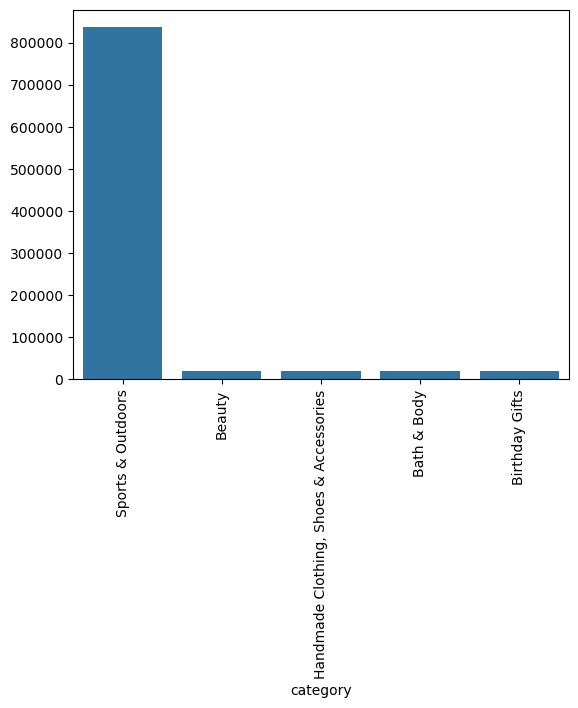

In [8]:
sns.barplot(x = frequency_table_top_5.index, y = frequency_table_top_5.values)

plt.xticks(rotation=90)

plt.tight_layout

2.2. For a subset of top categories, visualize their proportions using a pie chart.

<Axes: ylabel='count'>

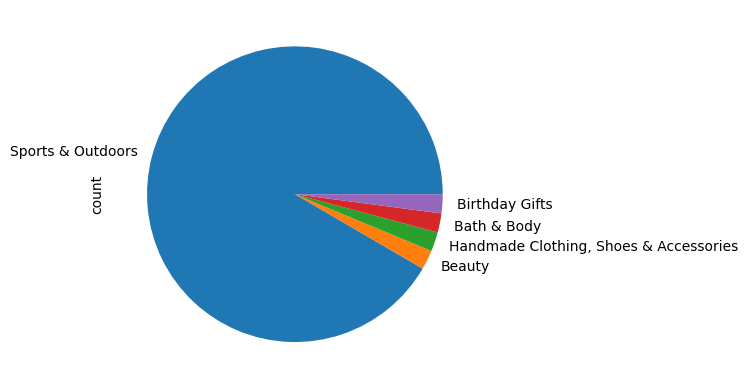

In [15]:
frequency_table_top_5.plot.pie()

Does any category dominate the listings?

It clearly does. Sports & Outdoors is the top category in terms of frequency, clearly winning the second one, Beauty. The barchart is the best way to visualize this, since the pie chart is very unclear regarding the actual numbers.


Part 2: Delving into Product Pricing

Business Question: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?


2.1 Calculate the mean, median, and mode for the price of products.

In [18]:
df["price"].mean()

np.float64(89.24380943923661)

In [19]:
df["price"].median()

19.09

In [20]:
df["price"].mode()

0    9.99
Name: price, dtype: float64

2.1. What's the average price point of products listed? How does this compare with the most common price point (mode)?

The average price is 89.2, which differs a lot from both the median, 19.09, and the mode, 9.99. This clearly shows there are outliers that increase the mean, which also means that maybe we should be focusing on the median or the mode for a better and more coherent analysis.

2.2. Determine the variance, standard deviation, range, and interquartile range for product price.

In [21]:
df["price"].var()

119445.4853225653

In [22]:
df["price"].std()

345.6088617535223

In [23]:
range_price = df["price"].max() - df["price"].min()
range_price

100000.0

In [24]:
q1 = df["price"].quantile(0.25)
q3 = df["price"].quantile(0.75)

iqr = q3 - q1

iqr

np.float64(36.0)

2.2. How varied are the product prices? Are there any indicators of a significant spread in prices?

These numbers show that we clearly have the 50% of the prices very much concentrated and a small number of outliers, with very high prices, which resut in a high std. The range, 100000, also demonstrates that the difference between the highest and the lowest price is huge, again, having the majority of prices around the median and a few very high prices. The high variance, 119445 also backs up the theory.

2.3. Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. If its hard to read these diagrams, think why this is, and explain how it could be solved..


<Axes: xlabel='price', ylabel='Count'>

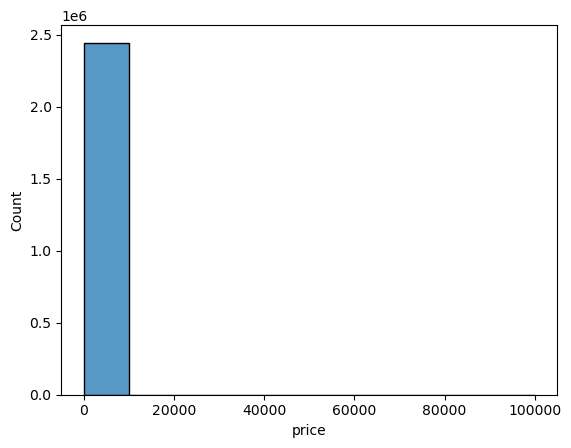

In [32]:
sns.histplot(df["price"], bins = 10)

This histogram is really difficult to read and really useless because we can also figure out, as we already understood from the measures before, that the majority of prices are between 0 - 10000 and that there are a couple of outliers that go quite high in price, up to 100000, but we cannot determine how many. Most probably just one per price range, but we cannot tell which range because it cannot be seen in the graph. This could be solved by dropping some of the outliers.

2.3. Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing.


<Axes: ylabel='price'>

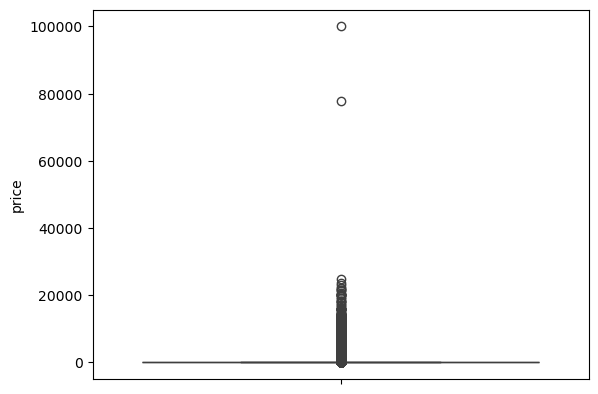

In [33]:
sns.boxplot(df["price"])

Once again, this graph is not very useful in understanding the complete data. However we can now clearly see that there are 2 outliers, which differ a lot from the rest of the data, one around 100000 and the other one around 80000. The rest of outliers marked by the box plot go up to 20000 aprox. 

Part 3: Unpacking Product Ratings

Business Question: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

3.1. Calculate the mean, median, and mode for the rating of products.

In [42]:
df["stars"].unique()

array([4.7, 4.6, 4.5, 4.8, 0. , 4.4, 4.3, 4.1, 4.9, 5. , 3.8, 3.6, 4. ,
       4.2, 3. , 3.9, 2.5, 3.4, 3.7, 3.2, 3.3, 3.5, 2.7, 2.1, 1. , 3.1,
       2. , 2.9, 2.8, 1.5, 2.2, 2.3, 2.6, 2.4, 1.4, 1.9, 1.8, 1.7, 1.6,
       1.2, 1.3, 1.1])

In [43]:
df["stars"].value_counts()

stars
0.0    1225641
4.5     151577
4.6     136995
4.4     136165
5.0     128492
4.3     112564
4.7      94566
4.2      86871
4.0      66089
4.1      65115
4.8      41858
3.9      36555
3.8      27876
3.7      21137
3.6      16219
3.5      14673
3.0      12819
4.9      11081
3.4      10355
1.0       8484
3.3       8269
3.2       5771
3.1       4679
2.0       3901
2.9       3341
2.8       2306
2.7       2104
2.5       2103
2.6       1579
2.4       1060
2.3        734
2.2        602
2.1        540
1.5        404
1.9        300
1.8        249
1.7        177
1.4        149
1.6        147
1.3         78
1.2         23
1.1          3
Name: count, dtype: int64

In [36]:
df["stars"].mean()

np.float64(2.152836472966066)

In [37]:
df["stars"].median()

0.0

In [38]:
df["stars"].mode()

0    0.0
Name: stars, dtype: float64

3.1. How do customers generally rate products? Is there a common trend?

Yes, there is. Customers generally rate products with a 0, since it is the median and the mode.

3.2. Determine the variance, standard deviation, and interquartile range for product rating.

In [44]:
df["stars"].var()

4.81743402976196

In [45]:
df["stars"].std()

2.1948653785054697

In [56]:
q1 = df["stars"].quantile(0.25)
q2 = df["stars"].quantile(0.5)
q3 = df["stars"].quantile(0.75)

iqr_rating = q3 - q1

print(q1)
print(q2)
print(q3)
print(iqr_rating)

0.0
0.0
4.4
4.4


3.2. Are the ratings consistent, or is there a wide variation in customer feedback?

The ratings show a wide variaton in customer feedback rather than being consistent. The IQR, 4.4, show that the middle 50% of the observations span a broad range of ratings. Plus we can see that both the 1st and 2nd quartile are 0, which shows that most rating are 0. The std, 2.19, is quite high in a scale that goes from 0 to 5, which also means a considerable dispersion.

3.3. Calculate the skewness and kurtosis for the rating column.

In [52]:
df["stars"].skew()

np.float64(0.08120735761080881)

In [53]:
df["stars"].kurtosis()

np.float64(-1.9260061280432994)

3.3. Are the ratings normally distributed, or do they lean towards higher or lower values?

Rating clearly lean towards lower values. The skewness is very close to the 0 or to a negative number and the kurtosis is very low.

3.4. Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

<Axes: xlabel='stars', ylabel='Count'>

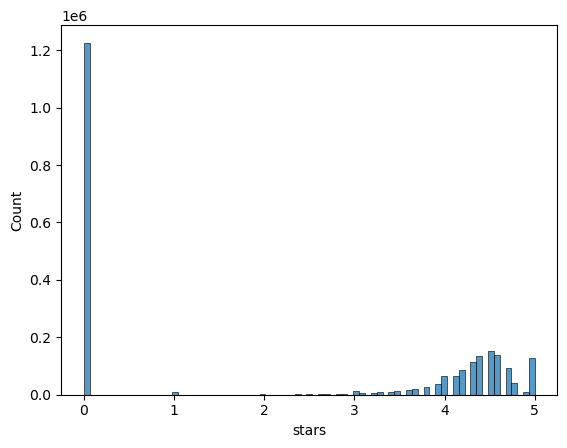

In [54]:
sns.histplot(data = df, x = "stars")

As we can see on the histogram, there is clearly a rating which stands out from the rest, that is the 0, with a frequency arounf 1.2 million observations, while the rest of ratings go only up to around 0,2.